In [2]:
!pip freeze | grep scikit-learn

scikit-learn==1.5.1


In [3]:
!python3 -V

Python 3.10.12


In [4]:
import pickle
import pandas as pd

In [6]:
with open('model/model.bin', 'rb') as f_in:
    dv, model = pickle.load(f_in)

/home/vjanga1/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DictVectorizer from version 1.5.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/vjanga1/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
categorical = ['PULocationID', 'DOLocationID']

def read_data(filename,):
    df = pd.read_parquet(filename,engine="fastparquet")
    
    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df['duration'] = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

    df[categorical] = df[categorical].fillna(-1).astype('int').astype('str')
    
    return df

In [9]:
df = read_data('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-03.parquet')


In [10]:
dicts = df[categorical].to_dict(orient='records')
X_val = dv.transform(dicts)
y_pred = model.predict(X_val)

In [11]:
y_pred

array([16.24590642, 26.1347962 , 11.88426424, ..., 11.59533603,
       13.11317847, 12.89999218])

In [11]:
# 1 question 

In [12]:
# What's the standard deviation of the predicted duration for this dataset?

In [12]:
y_pred.std()

6.247488852238703

In [13]:
# Q2. Preparing the output

In [15]:
year =2023
month = 3
df['ride_id'] = f'{year:04d}/{month:02d}_' + df.index.astype('str')

In [15]:
# question2 

In [16]:
# What's the size of the output file?

In [18]:
year = 2023
month =3
df['ride_id'] = f'{year:04d}/{month:02d}_' + df.index.astype('str')

In [16]:
df["prediction"] = y_pred

In [17]:
df_results = df[["ride_id","prediction"]]

In [18]:
output_file ="output.parquet"

df_results.to_parquet(
    output_file,
    engine='pyarrow',
    compression=None,
    index=False

)

In [19]:
import os
 
file_size = os.path.getsize(output_file)
print("File Size is :", file_size/1024/1024, "MB")

File Size is : 65.46188354492188 MB


In [20]:
# question 3

In [29]:
# Creating the scoring script
# answer : # python3 deployment.py

In [30]:
# question 4 

In [31]:
# what's the forst hash for the scikit -learn

In [ ]:
# Virtual environment 

# The first hash from the pipfile.lock
# sha256:00524bb23f4abb3a3bfff08aa32b9274843170c5b43855807e0f59670e2ac98c

In [21]:
# Q5. Parametrize the script

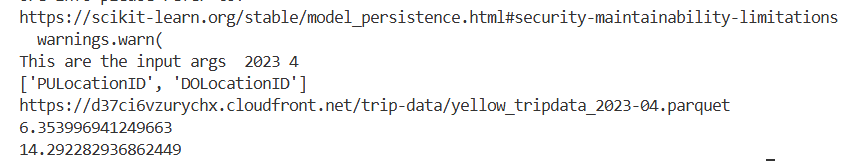

In [26]:
from IPython.display import Image, display

display(Image(filename="pics/1.png"))


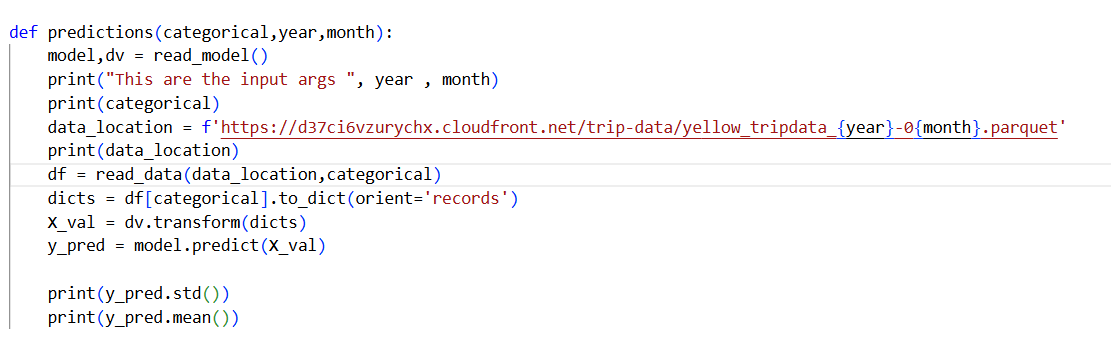

In [27]:
from IPython.display import Image, display

display(Image(filename="pics/2.png"))


In [22]:
#Q6. Docker container

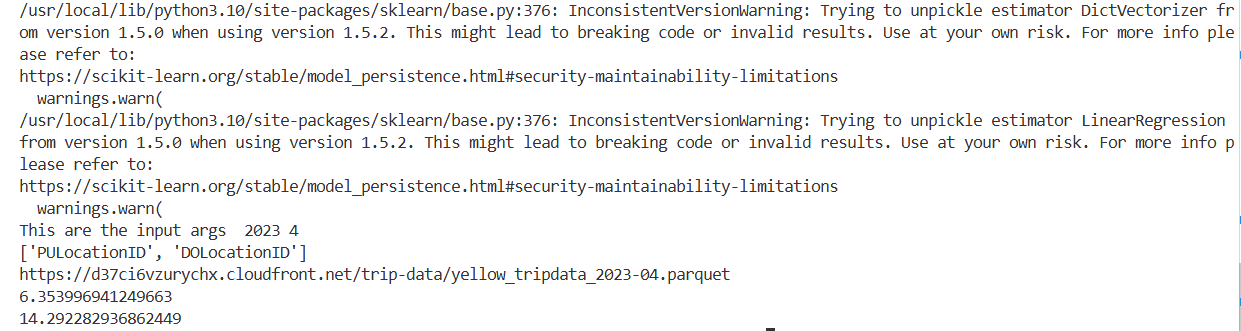

In [ ]:
from IPython.display import Image, display

display(Image(filename="pics/3.png"))
